# DTGS126. Characterizing Aberrations with a CNN

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/tutorials/1-getting-started/DTSG126_characterizing_aberrations_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack # Uncomment if running on Colab/Kaggle.

This tutorial demonstrates how to determine the aberration coefficient of an optical device using the image of a particle. You will consider spherical aberrations, but the example can straightforwardly be extended to other aberrations.

It is recommended to read [DTGS101_intro](./DTGS101_intro.ipynb) and [DTGS121_tracking_particle_cnn](./DTGS121_tracking_particle_cnn.ipynb) before this tutorial.

In [2]:
import random

import deeplay as dl
import deeptrack as dt
import numpy as np
import matplotlib.pyplot as plt
import torch

## 1. Defining the Features

Start by defining the features needed for this example:

* `fluorescence_microscope`: Flourescence microscope with a pixel size of 0.1 microns and a 128x128 camera (see also [DTATo20_optics](../3-advanced-topics/DTATo20_optics.ipynb))

* `particle`: Spherical particle roughly centered in the image, a micron out of focus (see also [DTAT301_features](../3-advanced-topics/DTAT301_features.ipynb))

* `aberration`: Spherical aberration with a coefficient between -4 and 4 (see also [DTATo40_aberrations](../3-advanced-topics/DTATo40_aberrations.ipynb))

* `noise`: A constant background illumantion and a Poisson noise with SNR 100 (see also [DTATo50_noises](../3-advanced-topics/DTATo50_noises.ipynb))

* `normalization`: Maps the image to values between 0 and 1

In particular, `SphericalAberration` is a wrapper of the more general `Zernike` feature, which introduces a phase to the pupil function based on the normalized Zernike polynomials. The property `coefficient` is a multiplier for the respective poynomial in the set of Zernike polynomials.

In [3]:
fluorescence_microscope = dt.Fluorescence(
    magnification=10,
    resolution=1e-6,
    wavelength=633e-9,
    output_region=(0, 0, 128, 128),
)

particle = dt.Sphere(
    position=lambda: np.random.randn(3) * (1, 1, 3) + (64, 64, 10),
    position_unit="pixel",
    intensity=10,
    radius=np.random.rand() * 1e-6 + 0.5e-6,
)

aberration = dt.SphericalAberration(
    coefficient=lambda: (2 * np.random.rand() - 1) * 4
)
fluorescence_microscope.pupil = aberration
noise = dt.Offset(offset=0.01) >> dt.Poisson(snr=100)

normalization = dt.NormalizeMinMax(min=0, max=1)

## 2. Combining the Features

To view the particle throught the aberrated microscope, call `fluorescence_microscope` with both the particle and the aberration. Then, chain the noise and normalization.

By calling `.resolve` with a coefficient, you override the value that the aberration generated for itself. Here, you can see the aberration at different strengths.

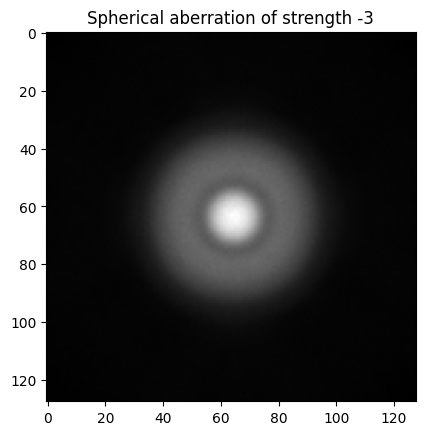

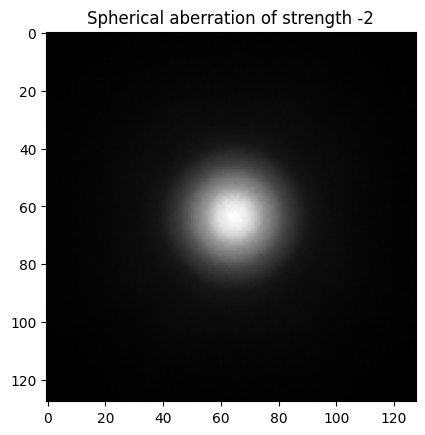

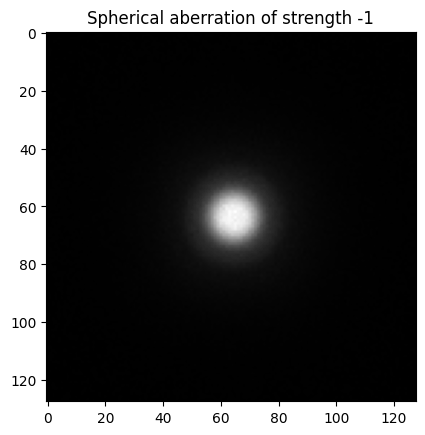

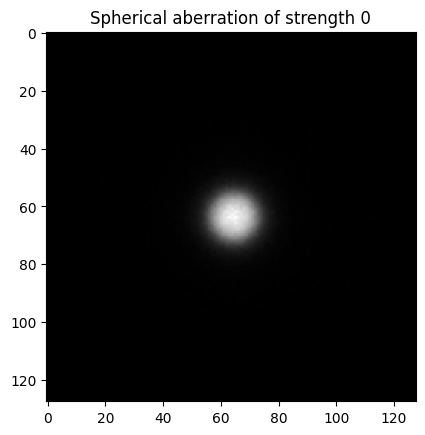

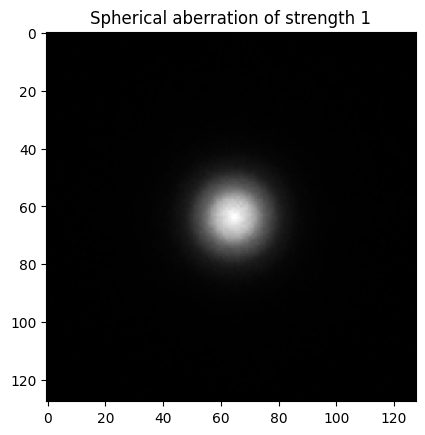

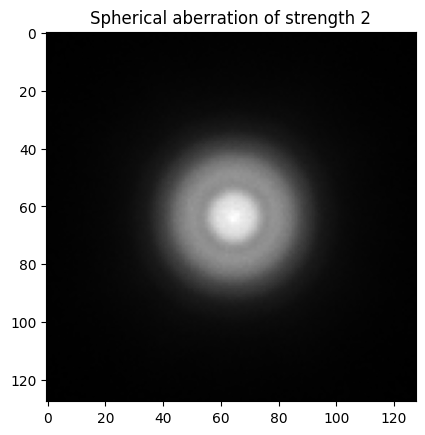

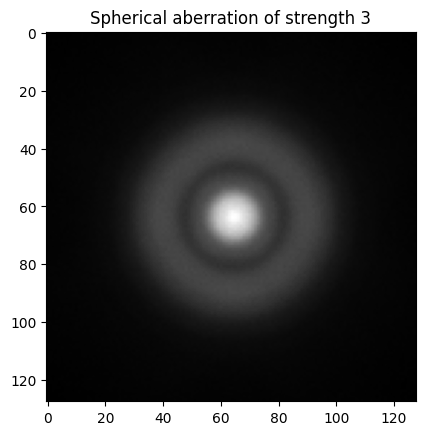

In [4]:
aberrated_particle = (
    fluorescence_microscope(particle, aberration=aberration)
    >> noise
    >> normalization
)

for coefficient in range(-3, 4):
    aberrated_particle.resolve(coefficient=coefficient)

    plt.title("Spherical aberration of strength {0}".format(coefficient))
    aberrated_particle.plot(cmap="gray")
    plt.show()

## 3. Creating the Dataset

Using the Pytorch `Dataset` class, create a dataset to use for training.

In [5]:
class Aberration_dataset(torch.utils.data.Dataset):

    def __init__(self, data_generator, device="auto", dataset_size=32):
        """Creates a dataset of aberrated particles on initialization."""

        self.device = device
        self.generate_data = data_generator

        dataset = []
        for _ in range(dataset_size):

            # Get aberration coefficient.
            coefficient = (2 * np.random.rand() - 1) * 4

            # Image the aberrated particle for the given coefficient.
            data = self.generate_data.resolve(
                coefficient=coefficient
            ).squeeze()

            # Get label.
            label = coefficient

            # Append image and label to dataset.
            dataset.append(
                [
                    torch.tensor(data, dtype=torch.float32).unsqueeze(0),
                    torch.tensor(label, dtype=torch.float32).unsqueeze(0),
                ]
            )

        self.dataset = dataset
        self.dataset_size = dataset_size

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        return random.choice(self.dataset)


# Initialize the dataset.
dataset = Aberration_dataset(aberrated_particle, dataset_size=256)

## 4. Creating the Model

You will use a standard convolutional neural network (CNN) with a multilayer perceptron as the dense top for this task. Since this is a regression task, you will use Mean Squared Error (MSE) as the loss metric.

In [6]:
# Define CNN base.
cnn_base = dl.ConvolutionalNeuralNetwork(
    in_channels=None,
    hidden_channels=[32, 32, 32, 64],
    out_channels=1,
)

# Add maxpooling to convolutional base.
cnn_base.blocks[-1].pooled(dl.Layer(torch.nn.MaxPool2d, 2).new())

# Define a dense top as a MLP.
dense_top = dl.MultiLayerPerceptron(
    in_features=None,
    hidden_features=[64, 64, 64],
    out_features=1,
)

# Define the model as a Deeplay sequential block.
model = dl.Sequential(cnn_base, dense_top)

Compile the model as a Deeplay regressor application.

In [7]:
aberration_regressor = dl.Regressor(
    model=model,
    loss=torch.nn.L1Loss(),
    optimizer=dl.Adam(lr=1e-3),
).build()

## 5. Training the Model

This can take a few minutes depending on your hardware.

-# TODO: Check why it doesn't converge always.

In [8]:
# Define the data loader.
train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
)

# Define the trainer.
trainer = dl.Trainer(max_epochs=100, accelerator="auto")

# Start training.
trainer.fit(aberration_regressor, train_loader)

/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:477: The t

Training: |          | 0/? [00:00<?, ?it/s]

Plot the loss evolution during training.

(<Figure size 1500x500 with 1 Axes>,
 array([[<Axes: title={'center': 'Loss'}, xlabel='Step'>]], dtype=object))

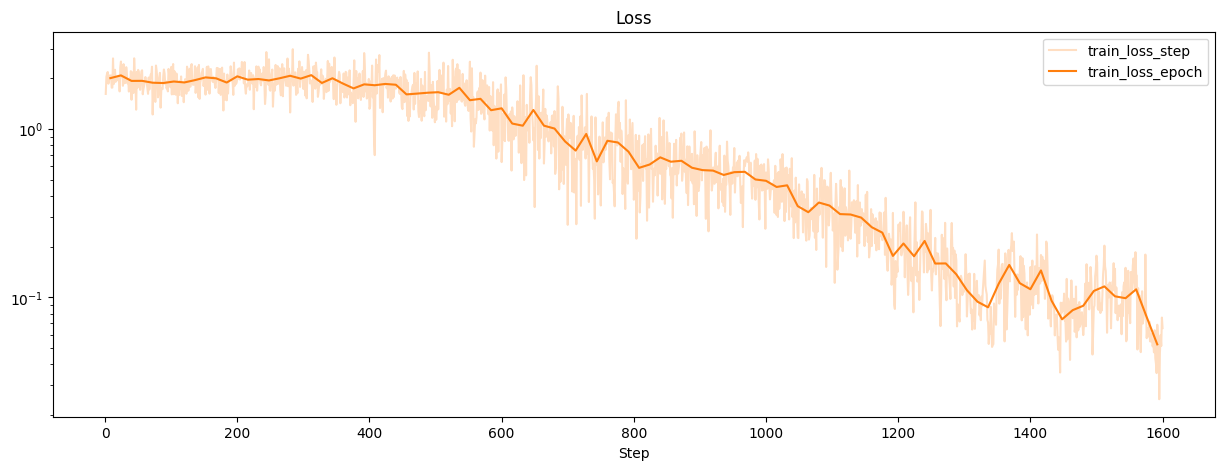

In [9]:
trainer.history.plot()

## 6. Validating the Results

Finally, validate the trained mode by generating a new dataset and plotting the predicted values of the spherical aberration coefficient against the ground truth.

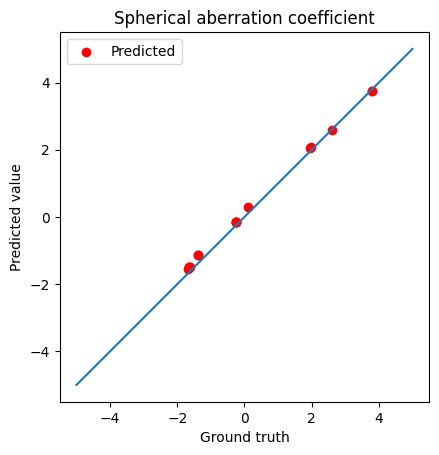

In [10]:
test_dataset_length = 16
test_dataset = Aberration_dataset(
    data_generator=aberrated_particle, dataset_size=test_dataset_length
)

# Iterate through the dataset.
labels = []
predictions = []
for i in range(test_dataset_length):
    image, label = test_dataset[i]
    prediction = model.predict(image)
    labels.append(label)
    predictions.append(prediction)

plt.scatter(labels, predictions, c="r", label="Predicted")

plt.plot([-5, 5], [-5, 5])

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Spherical aberration coefficient")
plt.xlabel("Ground truth")
plt.ylabel("Predicted value")
plt.legend()
plt.show()